In [1]:
!pip install -q --no-cache-dir --upgrade transformer_lens transformers einops

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 968.6/968.6 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 199.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 310.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 237.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import transformers
import transformer_lens

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("transformer_lens imported successfully")

from transformer_lens import HookedTransformer
print("HookedTransformer import: OK")

numpy: 2.0.2
torch: 2.10.0+cpu
transformers: 5.8.1
transformer_lens imported successfully
HookedTransformer import: OK


In [3]:
# This function intercepts the tensor (activation) as it passes through a layer
def my_analysis_hook(activation, hook):
    # 'activation' is the actual data (tensor) flowing through the network at this moment
    # 'hook.name' tells you exactly which layer and part of the network we are in
    
    print(f"--- Triggered at: {hook.name} ---")
    print(f"Data shape: {activation.shape}")
    
    # Example analysis: Let's see the average magnitude of the data flowing through
    avg_magnitude = torch.mean(torch.abs(activation)).item()
    print(f"Average activation magnitude: {avg_magnitude:.4f}\n")
    
    # You MUST return the activation. 
    # (If you wanted to edit the prompt's flow, you would modify the tensor here before returning it!)
    return activation

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# 1. Prepare a list to hold our hook configurations
fwd_hooks = []

model = HookedTransformer.from_pretrained("gpt2-small", device=device)
num_layers = model.cfg.n_layers
print("Loaded GPT-2 small")
print("layers :", num_layers)
print("heads  :", model.cfg.n_heads)
print("d_model:", model.cfg.d_model)

device: cpu


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
Loaded GPT-2 small
layers : 12
heads  : 12
d_model: 768


In [5]:
# 2. Append the hook to the residual stream of every layer
for layer in range(num_layers):
    # The name format targets the input to each transformer block
    hook_name = f"blocks.{layer}.hook_resid_pre" 
    
    # Append a tuple of (Where to hook, What function to run)
    fwd_hooks.append((hook_name, my_analysis_hook))

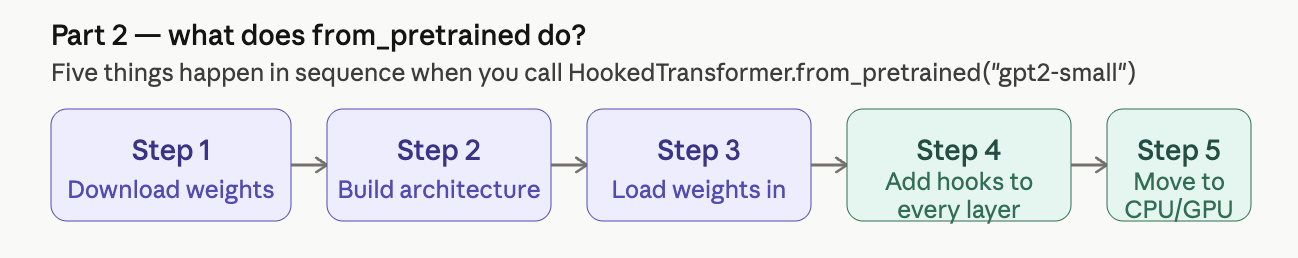

In [6]:

prompt = "Developer request: write a login function that securely stores passwords.\nCode:\n"

logits, cache = model.run_with_cache(prompt)
#Logits are the raw, unnormalized prediction scores output by the final layer of the language model 
#before they are turned into probabilities (using softmax)

# Instead of run_with_cache, we use run_with_hooks
logits = model.run_with_hooks(
    prompt,
    fwd_hooks=fwd_hooks
)

print("logits shape:", logits.shape)
print("number of cached activations:", len(cache))
print("sample cache keys:", list(cache.keys())[:15])


--- Triggered at: blocks.0.hook_resid_pre ---
Data shape: torch.Size([1, 17, 768])
Average activation magnitude: 0.1169

--- Triggered at: blocks.1.hook_resid_pre ---
Data shape: torch.Size([1, 17, 768])
Average activation magnitude: 1.0232

--- Triggered at: blocks.2.hook_resid_pre ---
Data shape: torch.Size([1, 17, 768])
Average activation magnitude: 1.2036

--- Triggered at: blocks.3.hook_resid_pre ---
Data shape: torch.Size([1, 17, 768])
Average activation magnitude: 1.6934

--- Triggered at: blocks.4.hook_resid_pre ---
Data shape: torch.Size([1, 17, 768])
Average activation magnitude: 1.8953

--- Triggered at: blocks.5.hook_resid_pre ---
Data shape: torch.Size([1, 17, 768])
Average activation magnitude: 2.0911

--- Triggered at: blocks.6.hook_resid_pre ---
Data shape: torch.Size([1, 17, 768])
Average activation magnitude: 2.2957

--- Triggered at: blocks.7.hook_resid_pre ---
Data shape: torch.Size([1, 17, 768])
Average activation magnitude: 2.5184

--- Triggered at: blocks.8.hook_

In [7]:
#By default, TransformerLens's to_tokens method will automatically prepend a 
#special BOS (Beginning of Sequence) token to the start of your prompt

tokens = model.to_tokens(prompt)

#In the context of your repository and the TransformerLens library,
#the line tokens = model.to_tokens(prompt) is used to convert your human-readable text 
#string into a format that the neural network can understand.

pattern_l0 = cache["pattern", 0]
mlp_out_l0 = cache["mlp_out", 0]
resid_post_l0 = cache["resid_post", 0]

print("tokens shape        :", tokens.shape)
print("pattern_l0 shape    :", pattern_l0.shape)
print("mlp_out_l0 shape    :", mlp_out_l0.shape)
print("resid_post_l0 shape :", resid_post_l0.shape)

tokens shape        : torch.Size([1, 17])
pattern_l0 shape    : torch.Size([1, 12, 17, 17])
mlp_out_l0 shape    : torch.Size([1, 17, 768])
resid_post_l0 shape : torch.Size([1, 17, 768])


In [8]:
example_text = """Developer prompt:
Write a login function that securely stores passwords.

Generated code:
def store_password(pw):
    db.save({"password": pw})

Question:
Is the implementation aligned with the request?
Answer:"""

print(example_text)

Developer prompt:
Write a login function that securely stores passwords.

Generated code:
def store_password(pw):
    db.save({"password": pw})

Question:
Is the implementation aligned with the request?
Answer:


In [9]:
def final_logits(model, text):
    logits = model(text)
    return logits[0, -1]

def logit_diff_yes_no(model, text, yes_token=" Yes", no_token=" No"):
    fl = final_logits(model, text)
    yes_id = model.to_single_token(yes_token)
    no_id = model.to_single_token(no_token)
    return (fl[yes_id] - fl[no_id]).item()

score = logit_diff_yes_no(model, example_text)
print("Yes-No logit diff:", score)

Yes-No logit diff: -0.4127931594848633


In [10]:
clean_text = """Developer prompt:
Write a login function that securely stores passwords.

Generated code:
import bcrypt
def store_password(pw):
    hashed = bcrypt.hashpw(pw.encode(), bcrypt.gensalt())
    db.save({"password": hashed})

Question:
Is the implementation aligned with the request?
Answer:"""

corrupted_text = """Developer prompt:
Write a login function that securely stores passwords.

Generated code:
def store_password(pw):
    db.save({"password": pw})

Question:
Is the implementation aligned with the request?
Answer:"""

print("clean score     :", logit_diff_yes_no(model, clean_text))
print("corrupted score :", logit_diff_yes_no(model, corrupted_text))

clean score     : -0.5209617614746094
corrupted score : -0.4127931594848633


In [11]:
from transformer_lens.model_bridge import TransformerBridge

# Load a model (eg GPT-2 Small)
bridge = TransformerBridge.boot_transformers("gpt2", device="cpu")

# Run the model and get logits and activations
logits, activations = bridge.run_with_cache("Hello World")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]